In [1]:
from superfv import AdvectionSolver, EulerSolver, plot_1d_slice, plot_timeseries
from superfv.initial_conditions import square

import matplotlib.pyplot as plt
import numpy as np

from functools import partial

In [2]:
sim0 = EulerSolver(
    ic=partial(square, bounds=(1, 2), P=1, vx=1),
    PAD={"rho": (1, np.inf), "P": (1e-12, np.inf)},
    nx=100,
    p=7,
    ZS=True,
    lazy_primitives="adaptive",
)

sim0.run(20.0)

print(min(sim0.minisnapshots["rho_min"]) - 1)

Step #5889 @ t=2.00e+01 | dt=1.44e-04 | min(rho)=1.00e+00, min(P)=1.00e+00 | E_cons=1.14e-13 | (ran in 10.76s)
-5.551115123125783e-16


In [3]:
sim1 = EulerSolver(
    ic=partial(square, bounds=(1, 2), P=1, vx=1),
    PAD={"rho": (1, np.inf), "P": (1e-12, np.inf)},
    nx=100,
    p=7,
    MOOD=True,
    lazy_primitives="full",
    cascade="first-order",
    NAD_rtol=1e-14,
    max_MOOD_iters=2,
)
sim1.run(20.0)

print(min(sim1.minisnapshots["rho_min"]) - 1)

/Users/jonathan/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #5458 @ t=2.00e+01 | dt=2.99e-03 | min(rho)=1.00e+00, min(P)=1.00e+00 | E_cons=1.71e-13 | (ran in 10.29s)
-4.440892098500626e-16


In [4]:
sim2 = EulerSolver(
    ic=partial(square, bounds=(1, 2), P=1, vx=1),
    PAD={"rho": (1, np.inf), "P": (1e-12, np.inf)},
    nx=100,
    p=7,
    MOOD=True,
    lazy_primitives="full",
    cascade="muscl0",
    MUSCL_limiter="moncen",
    NAD_rtol=1e-14,
    max_MOOD_iters=2,
)
sim2.run(20.0)

print(min(sim2.minisnapshots["rho_min"]) - 1)

/Users/jonathan/Desktop/superfv/superfv/finite_volume_solver.py:526: UserWarning: Turning off `face_fallback` since MOOD is used.
  warnings.warn("Turning off `face_fallback` since MOOD is used.")


Step #5459 @ t=2.00e+01 | dt=1.46e-04 | min(rho)=1.00e+00, min(P)=1.00e+00 | E_cons=5.68e-14 | (ran in 11.80s)
-1.2212453270876722e-15


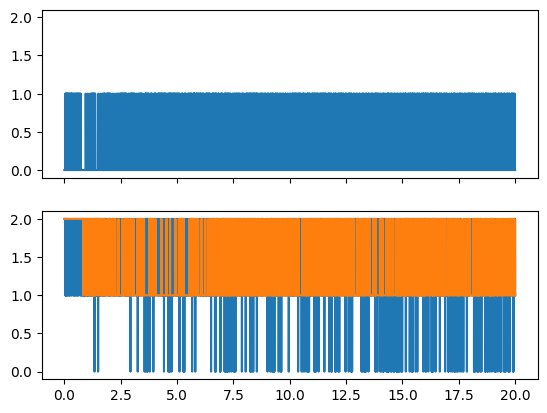

In [5]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

plot_timeseries(sim0, axs[0], "n_dt_revisions")
plot_timeseries(sim1, axs[1], "nfine_MOOD_iters")
plot_timeseries(sim2, axs[1], "nfine_MOOD_iters")

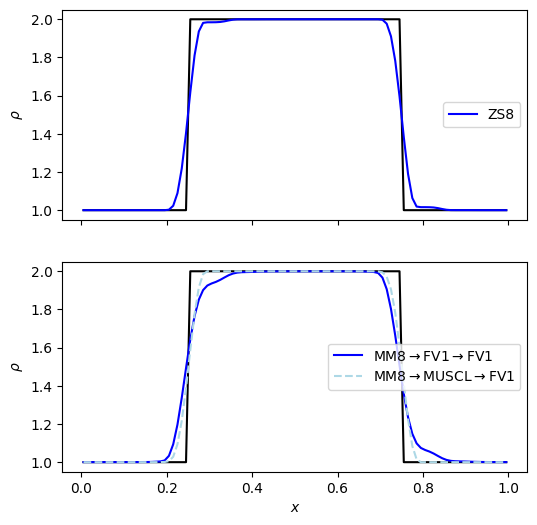

In [6]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(6, 6))

axs[0].set_ylabel(r"$\rho$")
axs[1].set_ylabel(r"$\rho$")
axs[1].set_xlabel(r"$x$")

plot_1d_slice(sim0, axs[0], "rho", t=0, color='k')
plot_1d_slice(sim0, axs[1], "rho", t=0, color='k')

plot_1d_slice(sim0, axs[0], "rho", color='blue', label="ZS8")

plot_1d_slice(sim1, axs[1], "rho", color='blue', label=r"MM8$\rightarrow$FV1$\rightarrow$FV1")
plot_1d_slice(sim2, axs[1], "rho", color='lightblue', linestyle='--', label=r"MM8$\rightarrow$MUSCL$\rightarrow$FV1")

axs[0].legend(loc="center right")
axs[1].legend(loc="center right")

In [7]:
fig.savefig("square.pdf")